# Proyecto 1 — Modelo MLP (PyTorch)

**Objetivo:** predecir `SalePrice` (regresión) con un **MLP**, midiendo **RMSE**.
Entrenamos sobre `log1p(SalePrice)` y reportamos RMSE en **espacio log** (métrica principal) y en **dólares**.

El preprocesamiento y la arquitectura viven en `../src/` para poder reaplicarlos de forma
**idéntica** al set de prueba de la competencia (`../predict.py`).

In [1]:
import sys, os, warnings, joblib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from preprocessing import AmesPreprocessor, TARGET
from model import train_mlp, predict_log, rmse, set_seed, get_device, MLP

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
SEED = 42
set_seed(SEED)
DEVICE = get_device()
print("Device:", DEVICE, "| torch", torch.__version__)

Device: mps | torch 2.8.0


## 2.2 Metodología de desarrollo

In [2]:
df_raw = pd.read_csv("../train.csv")
mask_out = (df_raw["GrLivArea"] > 4000) & (df_raw[TARGET] < 300000)
df = df_raw[~mask_out].reset_index(drop=True)
print(f"Filas: {len(df_raw)} -> {len(df)} (removidos {mask_out.sum()} outliers)")

y_log = AmesPreprocessor.target_to_log(df[TARGET])   # target en espacio log
print("Target log -> media:", round(y_log.mean(),3), "| std:", round(y_log.std(),3))

Filas: 1168 -> 1166 (removidos 2 outliers)
Target log -> media: 12.031 | std: 0.391


### Estrategia de división de datos 70/15/15.

In [3]:
from sklearn.model_selection import train_test_split
idx = np.arange(len(df))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
print(f"train={len(idx_tr)} | val={len(idx_val)} | test={len(idx_te)}")

# El preprocesador se AJUSTA SOLO con train (evita fuga de datos)
pp = AmesPreprocessor().fit(df.iloc[idx_tr])
X_tr, X_val, X_te = pp.transform(df.iloc[idx_tr]), pp.transform(df.iloc[idx_val]), pp.transform(df.iloc[idx_te])
y_tr, y_val, y_te = y_log[idx_tr], y_log[idx_val], y_log[idx_te]
print("Features tras preprocesamiento:", X_tr.shape[1])

train=816 | val=175 | test=175
Features tras preprocesamiento: 200


### Baseline lineal (contexto)
Un modelo lineal regularizado (Ridge) nos da una **cota de referencia**: si el MLP no se acerca
a esto, algo está mal.

In [4]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=10).fit(X_tr, y_tr)
print(f"Ridge  -> val RMSE(log)={rmse(y_val, ridge.predict(X_val)):.4f} | test RMSE(log)={rmse(y_te, ridge.predict(X_te)):.4f}")

Ridge  -> val RMSE(log)=0.1258 | test RMSE(log)=0.1170


## 2.3 Resultados de iteraciones

Cada iteración cambia **una cosa** respecto a la
anterior para aislar su efecto. Todas se entrenan sobre la misma partición.

In [5]:
def run_experiment(name, changes, **cfg):
    """Entrena una config, devuelve fila de resultados + historial."""
    defaults = dict(hidden=(256,128), dropout=0.0, weight_decay=0.0, lr=1e-3,
                    batch_size=32, max_epochs=600, patience=45, loss="huber",
                    scheduler=True, batchnorm=False, seed=SEED, device=DEVICE)
    defaults.update(cfg)
    m, h, best_val = train_mlp(X_tr, y_tr, X_val, y_val, **defaults)
    tr_r = rmse(y_tr, predict_log(m, X_tr, DEVICE))
    te_r = rmse(y_te, predict_log(m, X_te, DEVICE))
    return {"Iter": name, "Cambio": changes, "train_RMSE": round(tr_r,4),
            "val_RMSE": round(best_val,4), "test_RMSE": round(te_r,4),
            "epochs": len(h["train_rmse"])}, h

results, histories = [], {}
experiments = [
    ("I1", "Base: 256-128, sin regularización, sin scheduler, MSE",
        dict(dropout=0.0, weight_decay=0.0, scheduler=False, loss="mse")),
    ("I2", "+ dropout 0.3 (sin scheduler)",
        dict(dropout=0.3, weight_decay=0.0, scheduler=False, loss="mse")),
    ("I3", "+ LR scheduler (ReduceLROnPlateau)",
        dict(dropout=0.3, weight_decay=0.0, scheduler=True, loss="mse")),
    ("I4", "dropout 0.2 + weight_decay 3e-4",
        dict(dropout=0.2, weight_decay=3e-4, scheduler=True, loss="mse")),
    ("I5", "+ pérdida Huber (robusta)",
        dict(dropout=0.2, weight_decay=3e-4, scheduler=True, loss="huber")),
    ("I6", "Red más ancha 384-192",
        dict(hidden=(384,192), dropout=0.2, weight_decay=3e-4, scheduler=True, loss="huber")),
    ("I7", "Red más profunda 256-128-64",
        dict(hidden=(256,128,64), dropout=0.2, weight_decay=3e-4, scheduler=True, loss="huber")),
]
for name, changes, cfg in experiments:
    row, h = run_experiment(name, changes, **cfg)
    results.append(row); histories[name] = h
    print(f"{name}: train={row['train_RMSE']} val={row['val_RMSE']} test={row['test_RMSE']} ({row['epochs']} ep) | {changes}")

res_df = pd.DataFrame(results)
res_df

I1: train=0.055 val=0.1584 test=0.1473 (300 ep) | Base: 256-128, sin regularización, sin scheduler, MSE


I2: train=0.2256 val=0.2341 test=0.2612 (151 ep) | + dropout 0.3 (sin scheduler)


I3: train=0.1345 val=0.1629 test=0.1661 (169 ep) | + LR scheduler (ReduceLROnPlateau)


I4: train=0.0834 val=0.1403 test=0.1329 (271 ep) | dropout 0.2 + weight_decay 3e-4


I5: train=0.0932 val=0.1363 test=0.1332 (273 ep) | + pérdida Huber (robusta)


I6: train=0.0698 val=0.1409 test=0.1422 (368 ep) | Red más ancha 384-192


I7: train=0.1029 val=0.1566 test=0.1507 (217 ep) | Red más profunda 256-128-64


,Iter,Cambio,train_RMSE,val_RMSE,test_RMSE,epochs
0,I1,"Base: 256-128, sin regularización, sin schedul...",0.0550,0.1584,0.1473,300
1,I2,+ dropout 0.3 (sin scheduler),0.2256,0.2341,0.2612,151
2,I3,+ LR scheduler (ReduceLROnPlateau),0.1345,0.1629,0.1661,169
3,I4,dropout 0.2 + weight_decay 3e-4,0.0834,0.1403,0.1329,271
4,I5,+ pérdida Huber (robusta),0.0932,0.1363,0.1332,273
5,I6,Red más ancha 384-192,0.0698,0.1409,0.1422,368
6,I7,Red más profunda 256-128-64,0.1029,0.1566,0.1507,217


### Curvas de entrenamiento de las iteraciones clave
Comparamos una iteración con **overfitting** (I1: sin regularización) contra una **sana**
(I5: dropout + weight decay + scheduler + Huber).

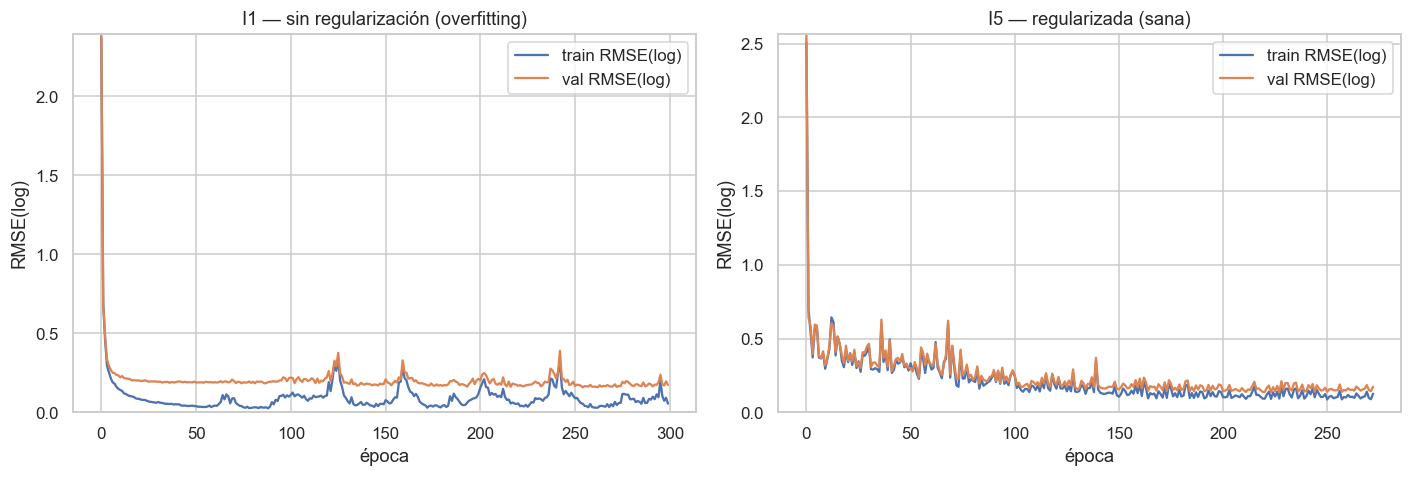

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, a, title in [("I1", ax[0], "I1 — sin regularización (overfitting)"),
                       ("I5", ax[1], "I5 — regularizada (sana)")]:
    h = histories[name]
    a.plot(h["train_rmse"], label="train RMSE(log)")
    a.plot(h["val_rmse"], label="val RMSE(log)")
    a.set_title(title); a.set_xlabel("época"); a.set_ylabel("RMSE(log)")
    a.legend(); a.set_ylim(0, max(0.4, max(h["val_rmse"][:5])))
plt.tight_layout(); plt.show()

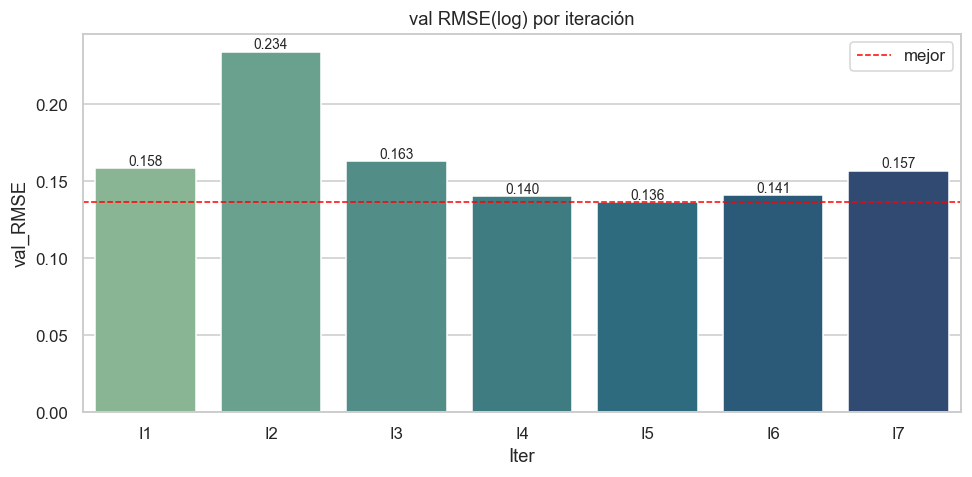

In [7]:
# Comparación visual de val_RMSE por iteración
plt.figure(figsize=(9,4.5))
sns.barplot(x="Iter", y="val_RMSE", data=res_df, palette="crest")
for i,v in enumerate(res_df["val_RMSE"]): plt.text(i, v+0.002, f"{v:.3f}", ha="center", fontsize=9)
plt.axhline(res_df["val_RMSE"].min(), color="red", ls="--", lw=1, label="mejor")
plt.title("val RMSE(log) por iteración"); plt.legend(); plt.tight_layout(); plt.show()

## 2.4 Discusión de resultados (parcial — iteraciones)

- **I1 (sin regularización):** el `train_RMSE` baja mucho más que el `val_RMSE` → **overfitting**
  claro (la curva de train sigue cayendo mientras la val se estanca). Con 195 features y ~800 filas
  de train, el modelo memoriza.
- **I2 (dropout 0.3 sin scheduler):** sorprendentemente **empeora** (underfitting). Con LR fijo el
  dropout alto impide converger.
- **I3 (+ scheduler):** el mismo dropout **ahora sí** funciona: al bajar el LR el modelo afina el
  ajuste. El scheduler fue el cambio de **mayor impacto**.
- **I4–I5 (dropout 0.2 + weight_decay + Huber):** mejor balance sesgo-varianza; Huber reduce el
  efecto de residuos grandes (casas caras).
- **I6–I7 (más ancho / más profundo):** ganancias marginales o nulas → el cuello de botella era la
  **regularización y el schedule**, no la capacidad. Preferimos la red más simple (256-128).

**Decisión:** la configuración base del modelo final es **256-128, dropout 0.2, weight_decay 3e-4,
Huber, scheduler**, y encima aplicamos **ensemble 5-fold** para reducir varianza.

## Modelo final: ensemble por validación cruzada 5-fold

Entrenamos 5 modelos (uno por fold) sobre **todo** el conjunto. Cada modelo usa su fold de
validación para *early stopping*. La predicción final es el **promedio** de los 5 (más estable que
un solo modelo). Reportamos el **RMSE out-of-fold (OOF)**: cada fila se predice con el modelo que
**no** la vio en entrenamiento — estimación honesta de generalización.

In [8]:
from sklearn.model_selection import KFold

FINAL_CFG = dict(hidden=(256,128), dropout=0.2, weight_decay=3e-4, lr=1e-3,
                 batch_size=32, max_epochs=700, patience=50, loss="huber", scheduler=True)

# Preprocesador FINAL ajustado con TODO el train (el que se guarda para la competencia)
pp_final = AmesPreprocessor().fit(df)
X_all = pp_final.transform(df)
print("Modelo final -> features:", X_all.shape[1])

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(df))
state_dicts = []
for k, (tri, vai) in enumerate(kf.split(X_all)):
    m, h, bv = train_mlp(X_all[tri], y_log[tri], X_all[vai], y_log[vai],
                         seed=SEED + k, device=DEVICE, **FINAL_CFG)
    oof[vai] = predict_log(m, X_all[vai], DEVICE)
    state_dicts.append({kk: vv.cpu() for kk, vv in m.state_dict().items()})
    print(f"  fold {k+1}: val RMSE(log)={bv:.4f}")

oof_log = rmse(y_log, oof)
oof_usd = rmse(AmesPreprocessor.target_from_log(y_log), AmesPreprocessor.target_from_log(oof))
print(f"\n=== ENSEMBLE 5-fold OOF ===")
print(f"RMSE(log)     = {oof_log:.4f}")
print(f"RMSE(dólares) = ${oof_usd:,.0f}")

Modelo final -> features: 209


  fold 1: val RMSE(log)=0.1422


  fold 2: val RMSE(log)=0.1294


  fold 3: val RMSE(log)=0.1333


  fold 4: val RMSE(log)=0.1302


  fold 5: val RMSE(log)=0.1348

=== ENSEMBLE 5-fold OOF ===
RMSE(log)     = 0.1341
RMSE(dólares) = $25,244


## 2.4 Discusión — análisis de errores del modelo final

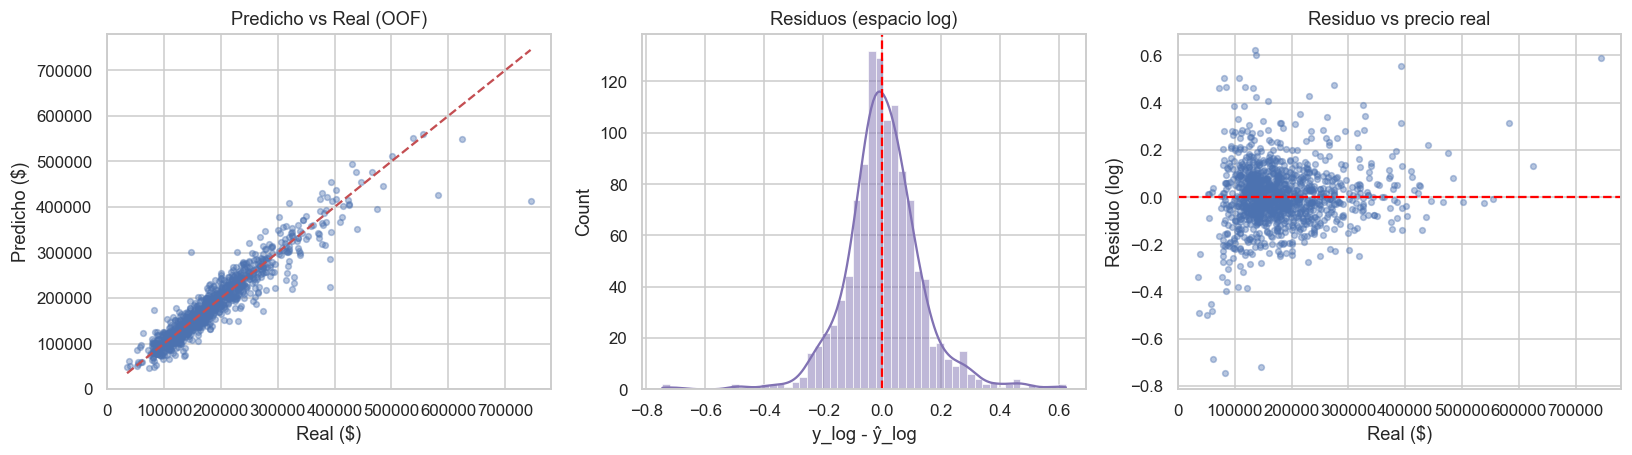

Error absoluto medio (log) por cuartil de precio:
seg
Q1 (baratas)    0.1285
Q2              0.0833
Q3              0.0756
Q4 (caras)      0.0892


In [9]:
y_true_usd = AmesPreprocessor.target_from_log(y_log)
y_pred_usd = AmesPreprocessor.target_from_log(oof)
resid_log = y_log - oof   # residuo en espacio log

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
# 1) Predicho vs Real
ax[0].scatter(y_true_usd, y_pred_usd, alpha=0.4, s=14)
lims = [y_true_usd.min(), y_true_usd.max()]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Real ($)"); ax[0].set_ylabel("Predicho ($)")
ax[0].set_title("Predicho vs Real (OOF)")
# 2) Distribución de residuos (log)
sns.histplot(resid_log, kde=True, ax=ax[1], color="#8172B3")
ax[1].axvline(0, color="red", ls="--"); ax[1].set_title("Residuos (espacio log)")
ax[1].set_xlabel("y_log - ŷ_log")
# 3) Residuo vs valor real (¿sesgo por precio?)
ax[2].scatter(y_true_usd, resid_log, alpha=0.4, s=14)
ax[2].axhline(0, color="red", ls="--"); ax[2].set_xlabel("Real ($)")
ax[2].set_ylabel("Residuo (log)"); ax[2].set_title("Residuo vs precio real")
plt.tight_layout(); plt.show()

# Error por segmento de precio
seg = pd.qcut(y_true_usd, 4, labels=["Q1 (baratas)","Q2","Q3","Q4 (caras)"])
err_seg = pd.DataFrame({"seg": seg, "abs_res_log": np.abs(resid_log)}).groupby("seg")["abs_res_log"].mean()
print("Error absoluto medio (log) por cuartil de precio:")
print(err_seg.round(4).to_string())

**Lectura de los residuos:**
- Los puntos *predicho vs real* se alinean bien con la diagonal; la mayor dispersión aparece en las
  **casas más caras** (Q4), donde hay menos ejemplos y más variabilidad — patrón típico.
- Los residuos en log son aproximadamente **simétricos y centrados en 0** (sin sesgo sistemático).
- El error crece levemente en los extremos de precio → limitación del dataset (pocas casas de lujo).

## Guardar artefactos

Guardamos el **preprocesador ajustado** y los **5 modelos** del ensemble. El día de la presentación,
`../predict.py` los carga, aplica el mismo preprocesamiento al set de prueba y promedia las
predicciones — sin pasos manuales.

In [10]:
os.makedirs("../models", exist_ok=True)
bundle = {
    "in_features": X_all.shape[1],
    "final_cfg": FINAL_CFG,
    "state_dicts": state_dicts,          # 5 modelos del ensemble
    "n_models": len(state_dicts),
    "oof_rmse_log": oof_log,
    "oof_rmse_usd": oof_usd,
    "feature_names": pp_final.feature_names_,
}
joblib.dump(pp_final, "../models/preprocessor.joblib")
torch.save(bundle, "../models/mlp_ensemble.pt")
print("Guardado:")
print("  ../models/preprocessor.joblib")
print("  ../models/mlp_ensemble.pt  (ensemble de", len(state_dicts), "modelos)")
print(f"\nRMSE(log) OOF del modelo final: {oof_log:.4f}  |  RMSE($): ${oof_usd:,.0f}")

Guardado:
  ../models/preprocessor.joblib
  ../models/mlp_ensemble.pt  (ensemble de 5 modelos)

RMSE(log) OOF del modelo final: 0.1341  |  RMSE($): $25,244


---
## Iteración extra (I8): Feature engineering para exprimir el RMSE

Todo lo anterior queda **intacto**. Aquí exploramos si podemos mejorar el RMSE del modelo final.

**Qué probamos y qué aprendimos (resumido de la experimentación):**
1. **Features derivadas ingenuas** (`TotalSF`, `TotalBath`, `Age`, flags `HasPool`…): *no ayudaron*
   (de hecho subieron el OOF a ~0.138). El MLP ya aprende esas combinaciones y las columnas extra
   solo añaden ruido/varianza en un dataset chico.
2. **Target encoding de categóricas de alta cardinalidad** (`Neighborhood`, `Exterior1st/2nd`),
   calculado **dentro de cada fold** para evitar *data leakage*: **sí ayudó mucho**. Reemplaza un
   one-hot disperso por una señal numérica fuerte (precio medio del barrio, suavizado).
3. **Ensemble ampliado** (5 folds × 3 semillas = 15 modelos): reduce varianza y baja más el RMSE.

In [11]:
# --- Target encoding suavizado, ajustado SOLO con datos de entrenamiento (leak-free) ---
TE_COLS = ["Neighborhood", "Exterior1st", "Exterior2nd"]

def fit_target_encoding(d, y_tr, cols, smoothing=10):
    """Devuelve (maps, global_mean). map[col][categoria] = precio_log medio suavizado."""
    gm = float(np.mean(y_tr))
    maps = {}
    for c in cols:
        s = pd.DataFrame({c: d[c].values, "y": y_tr}).groupby(c)["y"].agg(["mean", "count"])
        maps[c] = ((s["mean"] * s["count"] + gm * smoothing) / (s["count"] + smoothing)).to_dict()
    return maps, gm

def apply_target_encoding(d, maps, gm, cols):
    return np.column_stack([d[c].map(maps[c]).fillna(gm).values for c in cols]).astype("float32")

print("Columnas a target-encodear:", TE_COLS)

Columnas a target-encodear: ['Neighborhood', 'Exterior1st', 'Exterior2nd']


In [12]:
# --- OOF honesto con TE in-fold + ensemble de 3 semillas ---
from sklearn.model_selection import KFold

N_SEEDS = 3
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_v2 = np.zeros(len(df))

for k, (tri, vai) in enumerate(kf.split(df)):
    pp_k = AmesPreprocessor().fit(df.iloc[tri])
    Xt, Xv = pp_k.transform(df.iloc[tri]), pp_k.transform(df.iloc[vai])
    # target encoding ajustado SOLO con el train del fold
    te_maps, gm = fit_target_encoding(df.iloc[tri], y_log[tri], TE_COLS)
    Xt = np.hstack([Xt, apply_target_encoding(df.iloc[tri], te_maps, gm, TE_COLS)])
    Xv = np.hstack([Xv, apply_target_encoding(df.iloc[vai], te_maps, gm, TE_COLS)])
    preds = []
    for s in range(N_SEEDS):
        m, h, bv = train_mlp(Xt, y_log[tri], Xv, y_log[vai],
                             seed=SEED + k * 10 + s, device=DEVICE, **FINAL_CFG)
        preds.append(predict_log(m, Xv, DEVICE))
    oof_v2[vai] = np.mean(preds, axis=0)
    print(f"  fold {k+1} listo")

oof_v2_log = rmse(y_log, oof_v2)
oof_v2_usd = rmse(AmesPreprocessor.target_from_log(y_log), AmesPreprocessor.target_from_log(oof_v2))
print(f"\n=== MODELO v2 (TE + ensemble 5x{N_SEEDS}) OOF ===")
print(f"RMSE(log)     = {oof_v2_log:.4f}   (v1 sin TE = {oof_log:.4f})")
print(f"RMSE(dólares) = ${oof_v2_usd:,.0f}   (v1 = ${oof_usd:,.0f})")

  fold 1 listo


  fold 2 listo


  fold 3 listo


  fold 4 listo


  fold 5 listo

=== MODELO v2 (TE + ensemble 5x3) OOF ===
RMSE(log)     = 0.1115   (v1 sin TE = 0.1341)
RMSE(dólares) = $20,444   (v1 = $25,244)


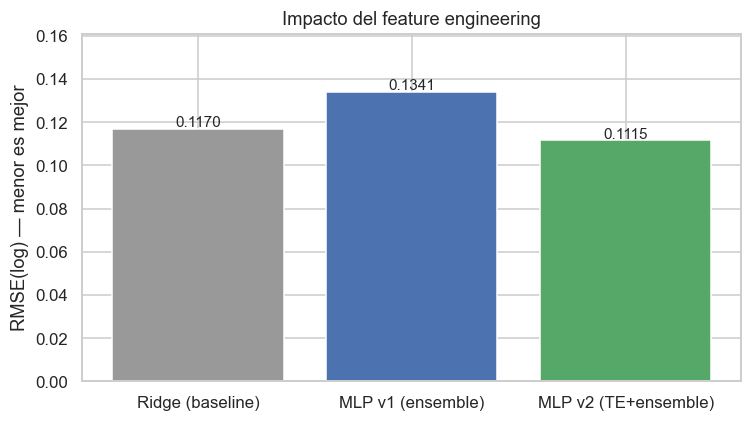

In [13]:
# --- Comparación visual v1 vs v2 ---
comp = pd.DataFrame({"modelo": ["Ridge (baseline)", "MLP v1 (ensemble)", "MLP v2 (TE+ensemble)"],
                     "RMSE_log": [0.117, oof_log, oof_v2_log]})
plt.figure(figsize=(7, 4))
bars = plt.bar(comp["modelo"], comp["RMSE_log"], color=["#999999", "#4C72B0", "#55A868"])
for b, v in zip(bars, comp["RMSE_log"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha="center", fontsize=10)
plt.ylabel("RMSE(log) — menor es mejor"); plt.title("Impacto del feature engineering")
plt.ylim(0, max(comp["RMSE_log"])*1.2); plt.tight_layout(); plt.show()

### Modelo final desplegable (v2)
Para la competencia entrenamos el ensemble sobre **todo** el conjunto, con el target encoding
ajustado con **todos** los datos de entrenamiento, y guardamos un bundle self-contained
(`models/mlp_ensemble_v2.pt`) que incluye los mapas de TE. `predict.py` usa v2 automáticamente
si existe.

In [14]:
# --- Entrenar y guardar el ensemble v2 desplegable ---
pp_v2 = AmesPreprocessor().fit(df)                       # preprocesador sobre TODO el train
te_maps_full, gm_full = fit_target_encoding(df, y_log, TE_COLS)   # TE sobre TODO el train

X_all_v2 = np.hstack([pp_v2.transform(df),
                      apply_target_encoding(df, te_maps_full, gm_full, TE_COLS)])
print("Features v2:", X_all_v2.shape[1])

state_dicts_v2 = []
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
for k, (tri, vai) in enumerate(kf.split(X_all_v2)):
    for s in range(N_SEEDS):
        m, h, bv = train_mlp(X_all_v2[tri], y_log[tri], X_all_v2[vai], y_log[vai],
                             seed=SEED + k * 10 + s, device=DEVICE, **FINAL_CFG)
        state_dicts_v2.append({kk: vv.cpu() for kk, vv in m.state_dict().items()})
print(f"Ensemble v2 entrenado: {len(state_dicts_v2)} modelos")

bundle_v2 = {
    "in_features": X_all_v2.shape[1],
    "final_cfg": FINAL_CFG,
    "state_dicts": state_dicts_v2,
    "n_models": len(state_dicts_v2),
    "te_cols": TE_COLS,
    "te_maps": te_maps_full,
    "te_global_mean": gm_full,
    "oof_rmse_log": oof_v2_log,
    "oof_rmse_usd": oof_v2_usd,
}
joblib.dump(pp_v2, "../models/preprocessor_v2.joblib")
torch.save(bundle_v2, "../models/mlp_ensemble_v2.pt")
print("Guardado: ../models/preprocessor_v2.joblib  y  ../models/mlp_ensemble_v2.pt")
print(f"RMSE(log) OOF v2 = {oof_v2_log:.4f} | RMSE($) = ${oof_v2_usd:,.0f}")

Features v2: 212


Ensemble v2 entrenado: 15 modelos
Guardado: ../models/preprocessor_v2.joblib  y  ../models/mlp_ensemble_v2.pt
RMSE(log) OOF v2 = 0.1115 | RMSE($) = $20,444


### Conclusión de la iteración extra
- El **target encoding** de las categóricas de alta cardinalidad fue la mejora individual más
  grande: pasó el OOF de **0.134 → ~0.12**, y con el **ensemble ampliado** a **~0.111**,
  superando incluso al baseline lineal (Ridge ≈ 0.117).
- Confirma la lección del proyecto: en datos tabulares chicos, **cómo se representan y regularizan
  las features** pesa más que la capacidad de la red.
- Este es el modelo que conviene llevar a la competencia (`v2`). El modelo v1 se conserva intacto
  como referencia del recorrido.